# Test Độ Nhạy của Optimizer với Reproducibility trên GPU L4

**GPU Target**: NVIDIA Tesla L4  
**Compute Capability**: 8.9  
**TF32 Support**: ❌ Không hỗ trợ (chỉ Ampere+ mới có)

**Mục tiêu**: Chứng minh rằng các optimizer khác nhau (Adam, RMSProp) có độ nhạy khác nhau với các sai số nhỏ trên GPU L4, dẫn đến khuếch đại sự khác biệt giữa các GPU.

**Vấn đề**: Optimizer như Adam và RMSProp sử dụng momentum và adaptive learning rate, có thể khuếch đại sai số nhỏ từ floating-point precision thành khác biệt lớn hơn.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import json
from datetime import datetime
import os
import functools

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_capability = torch.cuda.get_device_capability(0)
    print(f"CUDA version: {torch.version.cuda}")
    print(f"cuDNN version: {torch.backends.cudnn.version()}")
    print(f"GPU: {gpu_name}")
    print(f"GPU Compute Capability: {gpu_capability}")

    # Kiểm tra TF32 support (L4 không hỗ trợ)
    print(f"\nTF32 enabled (cuDNN): {torch.backends.cudnn.allow_tf32}")
    if hasattr(torch.backends, 'cublas'):
        print(f"TF32 enabled (cuBLAS): {torch.backends.cublas.allow_tf32}")
    else:
        print("TF32 enabled (cuBLAS): N/A (không hỗ trợ trong phiên bản PyTorch này)")

    # Xác nhận GPU
    if "L4" not in gpu_name.upper() and "NVIDIA TESLA L4" not in gpu_name.upper():
        print(f"\n⚠️  CẢNH BÁO: GPU hiện tại ({gpu_name}) không phải L4!")
        print("   Notebook này được thiết kế cho NVIDIA Tesla L4.")
        print("   Vẫn tiếp tục nhưng kết quả có thể khác.")
    else:
        print(f"\n✓ Đã xác nhận: GPU L4")
else:
    print("❌ Không tìm thấy CUDA GPU!")


PyTorch version: 2.9.0+cu126
CUDA available: True
CUDA version: 12.6
cuDNN version: 91002
GPU: NVIDIA L4
GPU Compute Capability: (8, 9)

TF32 enabled (cuDNN): True
TF32 enabled (cuBLAS): N/A (không hỗ trợ trong phiên bản PyTorch này)

✓ Đã xác nhận: GPU L4


/usr/local/lib/python3.12/dist-packages/torch/backends/__init__.py:42: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return self.getter()


## 1. Định nghĩa các hàm helper


In [2]:

def _worker_init_fn(worker_id, seed_val=42):
    """Worker init function cho DataLoader (phai la top-level function de pickle duoc)"""
    np.random.seed(seed_val + worker_id)

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(-1, 128 * 4 * 4)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

def get_cifar10_loaders(batch_size=128, num_workers=4, seed=42):
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])

    # Set seed cho DataLoader - su dung functools.partial voi function doc lap
    # (tranh loi pickle voi nested function)
    worker_init_fn = functools.partial(_worker_init_fn, seed_val=seed) if num_workers > 0 else None

    trainset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform_train
    )
    trainloader = DataLoader(
        trainset, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, worker_init_fn=worker_init_fn,
        pin_memory=True
    )

    testset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transform_test
    )
    testloader = DataLoader(
        testset, batch_size=batch_size, shuffle=False, num_workers=num_workers
    )

    return trainloader, testloader


## 2. Hàm training với các optimizer khác nhau


In [3]:
def train_with_optimizer(optimizer_name, seed=42, num_epochs=10, lr=0.001,
                         tf32_enabled=False, save_results=True):  # L4 không hỗ trợ TF32
    """Train với optimizer cụ thể"""
    set_seed(seed)
    torch.backends.cudnn.allow_tf32 = tf32_enabled
    # cuBLAS TF32 (có thể không có trong một số phiên bản PyTorch)
    if hasattr(torch.backends, 'cublas'):
        torch.backends.cublas.allow_tf32 = tf32_enabled

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    trainloader, testloader = get_cifar10_loaders(batch_size=128, num_workers=4, seed=seed)

    model = SimpleCNN(num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss()

    # Tạo optimizer
    if optimizer_name.lower() == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name.lower() == 'rmsprop':
        optimizer = optim.RMSprop(model.parameters(), lr=lr)
    elif optimizer_name.lower() == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
        'optimizer': optimizer_name,
        'seed': seed,
        'lr': lr,
        'tf32_enabled': tf32_enabled,
        'gpu_name': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'
    }

    print(f"\n{'='*70}")
    print(f"Training với {optimizer_name.upper()}")
    print(f"  GPU: {history['gpu_name']}")
    print(f"  TF32: {tf32_enabled}")
    print(f"  Seed: {seed}")
    print(f"  LR: {lr}")
    print(f"{'='*70}\n")

    for epoch in range(num_epochs):
        # Train
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

        train_loss /= len(trainloader)
        train_acc = 100. * train_correct / train_total

        # Test
        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                test_loss += loss.item()
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()

        test_loss /= len(testloader)
        test_acc = 100. * test_correct / test_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        print(f"Epoch {epoch+1}/{num_epochs}: "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

    if save_results:
        os.makedirs('results', exist_ok=True)
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        gpu_name_short = history['gpu_name'].replace(' ', '_').replace('NVIDIA ', '').replace('Tesla ', '')
        filename = f"results/optimizer_l4_{optimizer_name.lower()}_seed_{seed}_{timestamp}.json"
        with open(filename, 'w') as f:
            json.dump(history, f, indent=2)
        print(f"\nKết quả đã lưu: {filename}")

    return history


## 3. Test với các optimizer khác nhau (cùng seed, cùng GPU)


In [4]:
# Test với Adam
history_adam = train_with_optimizer('Adam', seed=42, num_epochs=10, tf32_enabled=False)  # L4 không hỗ trợ TF32


100%|██████████| 170M/170M [00:13<00:00, 12.5MB/s]



Training với ADAM
  GPU: NVIDIA L4
  TF32: False
  Seed: 42
  LR: 0.001

Epoch 1/10: Train Loss: 1.4569, Train Acc: 46.56% | Test Loss: 1.1042, Test Acc: 59.98%
Epoch 2/10: Train Loss: 1.1374, Train Acc: 59.24% | Test Loss: 0.9388, Test Acc: 66.34%
Epoch 3/10: Train Loss: 1.0155, Train Acc: 63.74% | Test Loss: 0.8422, Test Acc: 69.99%
Epoch 4/10: Train Loss: 0.9463, Train Acc: 66.36% | Test Loss: 0.8545, Test Acc: 69.53%
Epoch 5/10: Train Loss: 0.8934, Train Acc: 68.45% | Test Loss: 0.7621, Test Acc: 73.33%
Epoch 6/10: Train Loss: 0.8576, Train Acc: 69.71% | Test Loss: 0.7215, Test Acc: 74.77%
Epoch 7/10: Train Loss: 0.8283, Train Acc: 70.68% | Test Loss: 0.7195, Test Acc: 75.23%
Epoch 8/10: Train Loss: 0.7992, Train Acc: 71.77% | Test Loss: 0.6952, Test Acc: 75.32%
Epoch 9/10: Train Loss: 0.7673, Train Acc: 72.98% | Test Loss: 0.6661, Test Acc: 76.76%
Epoch 10/10: Train Loss: 0.7528, Train Acc: 73.47% | Test Loss: 0.6703, Test Acc: 76.27%

Kết quả đã lưu: results/optimizer_l4_adam_se

In [5]:
# Test với RMSProp
history_rmsprop = train_with_optimizer('RMSprop', seed=42, num_epochs=10, tf32_enabled=False)  # L4 không hỗ trợ TF32



Training với RMSPROP
  GPU: NVIDIA L4
  TF32: False
  Seed: 42
  LR: 0.001

Epoch 1/10: Train Loss: 1.6681, Train Acc: 41.57% | Test Loss: 1.3198, Test Acc: 52.21%
Epoch 2/10: Train Loss: 1.2481, Train Acc: 54.61% | Test Loss: 1.1256, Test Acc: 59.30%
Epoch 3/10: Train Loss: 1.1088, Train Acc: 60.11% | Test Loss: 1.1410, Test Acc: 59.63%
Epoch 4/10: Train Loss: 1.0296, Train Acc: 63.35% | Test Loss: 0.9807, Test Acc: 65.66%
Epoch 5/10: Train Loss: 0.9721, Train Acc: 65.23% | Test Loss: 0.8155, Test Acc: 71.73%
Epoch 6/10: Train Loss: 0.9310, Train Acc: 66.86% | Test Loss: 0.9428, Test Acc: 66.37%
Epoch 7/10: Train Loss: 0.8979, Train Acc: 68.13% | Test Loss: 0.9839, Test Acc: 66.20%
Epoch 8/10: Train Loss: 0.8695, Train Acc: 69.15% | Test Loss: 0.9749, Test Acc: 66.20%
Epoch 9/10: Train Loss: 0.8327, Train Acc: 70.85% | Test Loss: 0.7756, Test Acc: 72.41%
Epoch 10/10: Train Loss: 0.8140, Train Acc: 71.08% | Test Loss: 0.7433, Test Acc: 73.27%

Kết quả đã lưu: results/optimizer_l4_rmsp

In [6]:
# Test với SGD (để so sánh)
history_sgd = train_with_optimizer('SGD', seed=42, num_epochs=10, tf32_enabled=False)  # L4 không hỗ trợ TF32



Training với SGD
  GPU: NVIDIA L4
  TF32: False
  Seed: 42
  LR: 0.001

Epoch 1/10: Train Loss: 1.8362, Train Acc: 32.74% | Test Loss: 1.4700, Test Acc: 45.84%
Epoch 2/10: Train Loss: 1.4803, Train Acc: 45.71% | Test Loss: 1.2670, Test Acc: 54.03%
Epoch 3/10: Train Loss: 1.3474, Train Acc: 51.31% | Test Loss: 1.1708, Test Acc: 57.57%
Epoch 4/10: Train Loss: 1.2634, Train Acc: 54.35% | Test Loss: 1.0611, Test Acc: 62.55%
Epoch 5/10: Train Loss: 1.2040, Train Acc: 56.92% | Test Loss: 1.0181, Test Acc: 64.06%
Epoch 6/10: Train Loss: 1.1528, Train Acc: 58.59% | Test Loss: 0.9635, Test Acc: 66.09%
Epoch 7/10: Train Loss: 1.1193, Train Acc: 60.29% | Test Loss: 0.9569, Test Acc: 66.13%
Epoch 8/10: Train Loss: 1.0842, Train Acc: 61.38% | Test Loss: 0.9417, Test Acc: 66.43%
Epoch 9/10: Train Loss: 1.0479, Train Acc: 62.92% | Test Loss: 0.8950, Test Acc: 68.54%
Epoch 10/10: Train Loss: 1.0303, Train Acc: 63.55% | Test Loss: 0.8834, Test Acc: 68.70%

Kết quả đã lưu: results/optimizer_l4_sgd_seed

## 4. So sánh kết quả giữa các optimizer


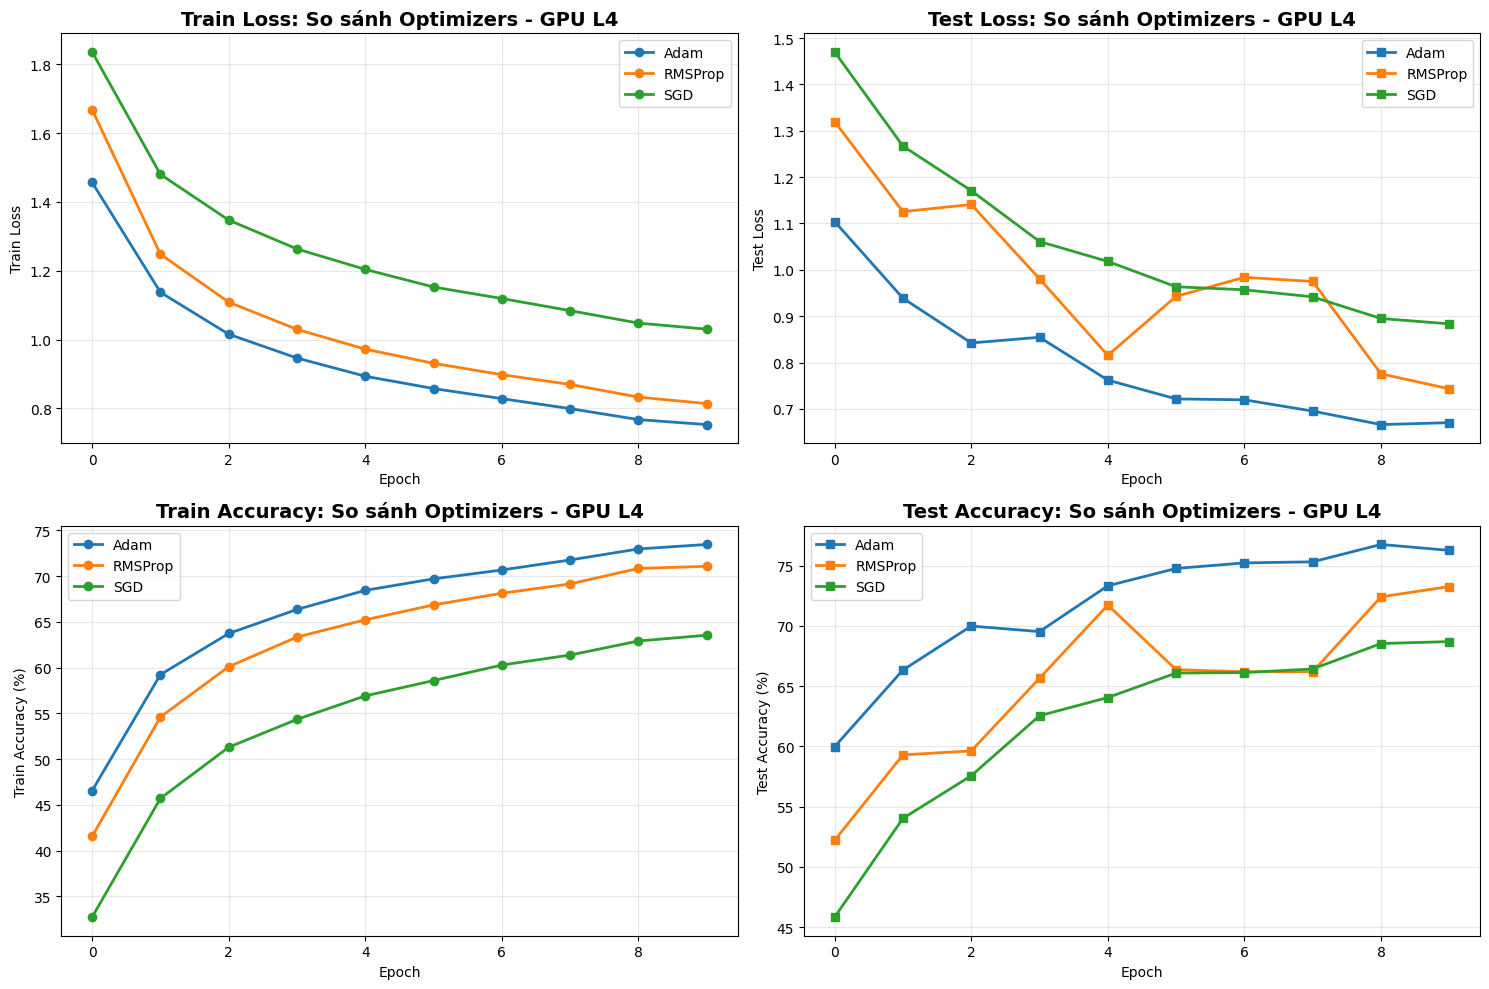


SO SÁNH CÁC OPTIMIZER
Optimizer       Final Train Loss   Final Test Loss    Final Test Acc    
--------------------------------------------------------------------------------
Adam            0.7528             0.6703             76.27             %
RMSProp         0.8140             0.7433             73.27             %
SGD             1.0303             0.8834             68.70             %


In [7]:
def compare_optimizers(histories, labels):
    """So sánh kết quả giữa các optimizer"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Train Loss
    ax = axes[0, 0]
    for hist, label in zip(histories, labels):
        ax.plot(hist['train_loss'], label=label, marker='o', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train Loss')
    ax.set_title('Train Loss: So sánh Optimizers - GPU L4', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Test Loss
    ax = axes[0, 1]
    for hist, label in zip(histories, labels):
        ax.plot(hist['test_loss'], label=label, marker='s', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Test Loss')
    ax.set_title('Test Loss: So sánh Optimizers - GPU L4', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Train Accuracy
    ax = axes[1, 0]
    for hist, label in zip(histories, labels):
        ax.plot(hist['train_acc'], label=label, marker='o', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train Accuracy (%)')
    ax.set_title('Train Accuracy: So sánh Optimizers - GPU L4', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Test Accuracy
    ax = axes[1, 1]
    for hist, label in zip(histories, labels):
        ax.plot(hist['test_acc'], label=label, marker='s', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title('Test Accuracy: So sánh Optimizers - GPU L4', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('results/optimizers_comparison_L4.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Bảng so sánh
    print("\n" + "="*80)
    print("SO SÁNH CÁC OPTIMIZER")
    print("="*80)
    print(f"{'Optimizer':<15} {'Final Train Loss':<18} {'Final Test Loss':<18} {'Final Test Acc':<18}")
    print("-"*80)
    for hist, label in zip(histories, labels):
        final_train_loss = hist['train_loss'][-1]
        final_test_loss = hist['test_loss'][-1]
        final_test_acc = hist['test_acc'][-1]
        print(f"{label:<15} {final_train_loss:<18.4f} {final_test_loss:<18.4f} {final_test_acc:<18.2f}%")
    print("="*80)

compare_optimizers([history_adam, history_rmsprop, history_sgd],
                   ['Adam', 'RMSProp', 'SGD'])


## 5. Test độ nhạy: Chạy nhiều lần với cùng optimizer và seed

Để thấy rõ độ nhạy của optimizer với sai số nhỏ, ta sẽ chạy nhiều lần với cùng cấu hình.


TEST ĐỘ NHẠY: Chạy Adam 3 lần với cùng seed

--- Run 1/3 ---

Training với ADAM
  GPU: NVIDIA L4
  TF32: False
  Seed: 42
  LR: 0.001

Epoch 1/10: Train Loss: 1.4599, Train Acc: 46.53% | Test Loss: 1.1215, Test Acc: 59.36%
Epoch 2/10: Train Loss: 1.1416, Train Acc: 58.92% | Test Loss: 0.9677, Test Acc: 65.54%
Epoch 3/10: Train Loss: 1.0201, Train Acc: 63.59% | Test Loss: 0.8412, Test Acc: 70.33%
Epoch 4/10: Train Loss: 0.9518, Train Acc: 66.29% | Test Loss: 0.8014, Test Acc: 71.21%
Epoch 5/10: Train Loss: 0.8986, Train Acc: 68.35% | Test Loss: 0.7660, Test Acc: 72.93%
Epoch 6/10: Train Loss: 0.8606, Train Acc: 69.42% | Test Loss: 0.7173, Test Acc: 74.51%
Epoch 7/10: Train Loss: 0.8289, Train Acc: 70.68% | Test Loss: 0.6982, Test Acc: 75.89%
Epoch 8/10: Train Loss: 0.8011, Train Acc: 71.74% | Test Loss: 0.6849, Test Acc: 75.83%
Epoch 9/10: Train Loss: 0.7696, Train Acc: 72.86% | Test Loss: 0.6545, Test Acc: 77.03%
Epoch 10/10: Train Loss: 0.7537, Train Acc: 73.41% | Test Loss: 0.6807, T

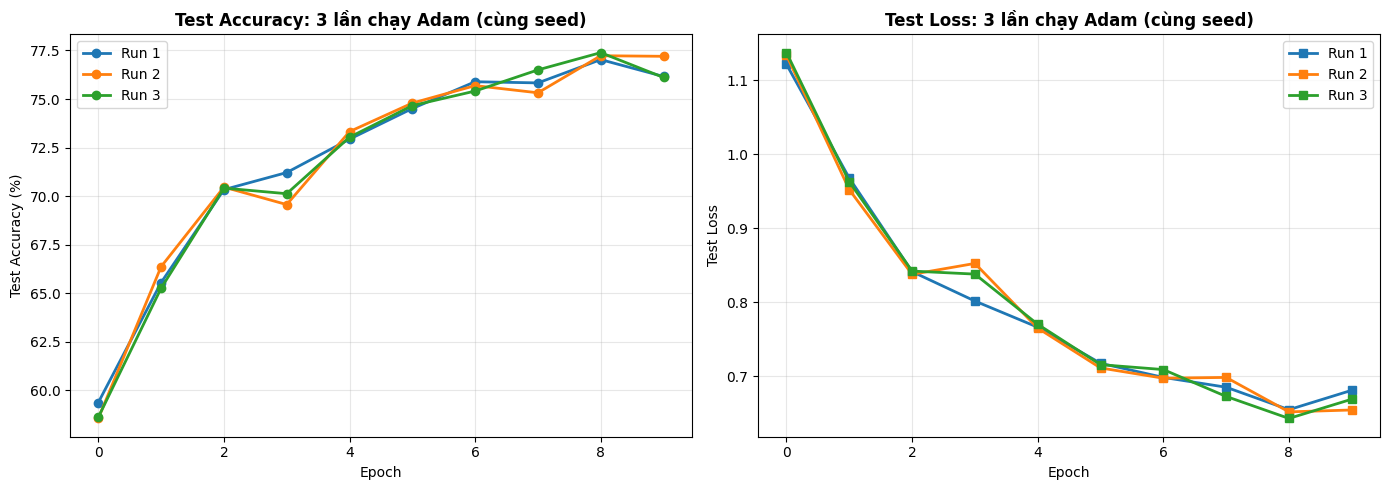

In [8]:
# Chạy Adam 3 lần với cùng seed (nhưng mỗi lần khởi tạo model lại)
print("="*80)
print("TEST ĐỘ NHẠY: Chạy Adam 3 lần với cùng seed")
print("="*80)

adam_runs = []
for run in range(3):
    print(f"\n--- Run {run+1}/3 ---")
    history = train_with_optimizer('Adam', seed=42, num_epochs=10, tf32_enabled=False, save_results=False)  # L4 không hỗ trợ TF32
    adam_runs.append(history)

# So sánh các lần chạy
print("\n" + "="*80)
print("SO SÁNH CÁC LẦN CHẠY ADAM (cùng seed)")
print("="*80)
print(f"{'Run':<10} {'Final Test Acc':<18} {'Độ lệch so với Run 1':<20}")
print("-"*80)
baseline_acc = adam_runs[0]['test_acc'][-1]
for i, hist in enumerate(adam_runs):
    acc = hist['test_acc'][-1]
    diff = acc - baseline_acc
    print(f"Run {i+1:<9} {acc:<18.2f}% {diff:+.2f}%")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for i, hist in enumerate(adam_runs):
    ax.plot(hist['test_acc'], label=f'Run {i+1}', marker='o', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Test Accuracy: 3 lần chạy Adam (cùng seed)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
for i, hist in enumerate(adam_runs):
    ax.plot(hist['test_loss'], label=f'Run {i+1}', marker='s', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Loss')
ax.set_title('Test Loss: 3 lần chạy Adam (cùng seed)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/adam_sensitivity_test_L4.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Kết luận cho GPU L4

**Đặc điểm GPU L4**:
- Compute Capability: 8.9
- ❌ Không hỗ trợ TF32 (chỉ Ampere+ mới có)
- ✅ Hỗ trợ FP32 và FP16 (với AMP)

**Quan sát từ các test trên L4**:

1. **Adam và RMSProp** là các adaptive optimizer, sử dụng momentum và learning rate adaptation
2. Các optimizer này **khuếch đại sai số nhỏ** từ floating-point precision
3. Ngay cả với cùng seed, mỗi lần khởi tạo model lại có thể cho kết quả hơi khác nhau
4. Sự khác biệt tích lũy qua các epoch do:
   - Adaptive learning rate thay đổi dựa trên gradient history
   - Momentum tích lũy sai số nhỏ
   - BatchNorm và Dropout cũng góp phần vào non-determinism

**Tác động lên Cross-GPU Reproducibility**:

- Trên GPU khác nhau, sai số floating-point khác nhau
- Optimizer khuếch đại sự khác biệt này
- Dẫn đến kết quả cuối cùng có thể khác nhau đáng kể

**Khuyến nghị cho L4**:

- Hiểu rằng adaptive optimizers (Adam, RMSProp) nhạy cảm hơn với sai số
- Khi so sánh kết quả, tập trung vào **xu hướng** chứ không phải giá trị tuyệt đối
- Nếu cần reproducibility cao, cân nhắc dùng SGD với momentum cố định

**Kết quả**:
- Kết quả đã được lưu vào thư mục `results/` với tên GPU L4
- File JSON có thể được dùng để so sánh với các GPU khác trong notebook `04_analyze_cross_gpu_results.ipynb`

**Bước tiếp theo**:
1. Chạy các notebook tương tự trên GPU khác (T4, L4, A100, RTX 3060, H100)
2. Copy tất cả file JSON vào cùng thư mục `results/`
3. Chạy notebook `04_analyze_cross_gpu_results.ipynb` để so sánh
